C:\Users\ESTUDANTE\AppData\Roaming\Python\Python314\site-packages\fastf1\plotting\_plotting.py:56: FutureWarning: The `misc_mpl_mods` argument was dropped from `.setup_mpl()` in version 3.6.0 and has no effect anymore. It will be removed in a future version of FastF1.
  warnings.warn(
core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages

------------------------------
Tempo do Verstappen (Red Bull): 80.307s
Tempo do Leclerc (Ferrari): 80.361s
------------------------------
🏆 O Verstappen foi mais rápido por 0.054!


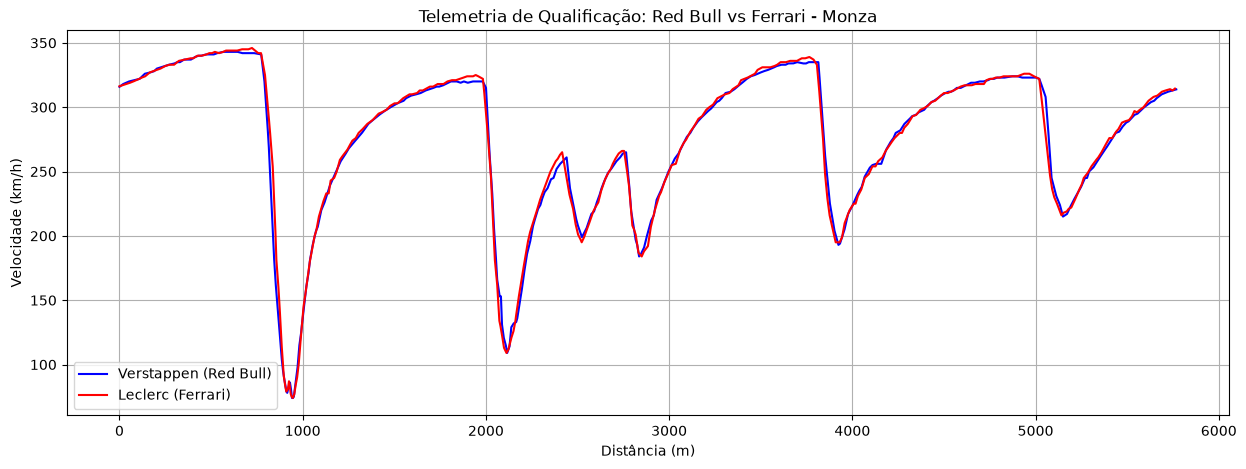

In [10]:
import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt
import os

os.makedirs('cache', exist_ok=True)
fastf1.Cache.enable_cache('cache')

fastf1.plotting.setup_mpl(misc_mpl_mods=False)

sessao = fastf1.get_session(2023, 'Italy', 'Q')
sessao.load()

volta_rbr = sessao.laps.pick_driver('VER').pick_fastest()
volta_fer = sessao.laps.pick_driver('LEC').pick_fastest()

tel_rbr = volta_rbr.get_telemetry()
tel_fer = volta_fer.get_telemetry()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(tel_rbr['Distance'], tel_rbr['Speed'], label='Verstappen (Red Bull)', color='blue')
ax.plot(tel_fer['Distance'], tel_fer['Speed'], label='Leclerc (Ferrari)', color='red')

ax.set_xlabel('Distância (m)')
ax.set_ylabel('Velocidade (km/h)')
ax.set_title('Telemetria de Qualificação: Red Bull vs Ferrari - Monza')
ax.legend()
plt.grid(True)

tempo_rbr = round(volta_rbr['LapTime'].total_seconds(), 3)
tempo_fer = round(volta_fer['LapTime'].total_seconds(), 3)

print("-" * 30)
print(f"Tempo do Verstappen (Red Bull): {tempo_rbr}s")
print(f"Tempo do Leclerc (Ferrari): {tempo_fer}s")

print("-" * 30)
if tempo_rbr < tempo_fer:
    diferenca = tempo_fer - tempo_rbr
    print(f"🏆 O Verstappen foi mais rápido por {diferenca:.3f}!")
elif tempo_fer < tempo_rbr:
    diferenca = tempo_rbr - tempo_fer
    print(f"🏆 O Leclerc foi mais rápido por {diferenca:.3f}!")
else:
    print("Empate exato!")

plt.show()